In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import pandas_datareader.data as web

In [2]:
# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

<Axes: xlabel='DATE'>

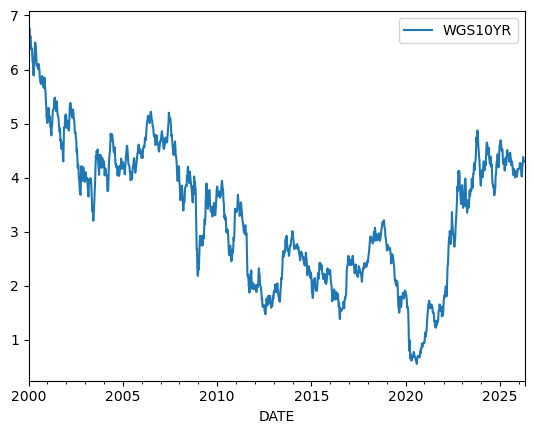

In [3]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01')
rate.plot()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
device

device(type='cpu')

In [6]:
# Переведем ряда массив Numpy
series = rate.iloc[:,0].values

# scaler = MinMaxScaler()
# series = scaler.fit_predict(series)

In [7]:
series

array([6.56, 6.66, 6.77, ..., 4.31, 4.29, 4.3 ], shape=(1373,))

In [8]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [9]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

In [10]:
train_dataset = TensorDataset(X_tensor, y_tensor)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [12]:
model = nn.Sequential(
    nn.Linear(n_lags, 30),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(30, fh)
).to(device)

In [13]:
# Обучение
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
epochs = 100


for epoch in range(epochs):
	total_loss = 0.0
	model.train()

	for batch_X, batch_y in train_loader:
		batch_X, batch_y = batch_X.to(device), batch_y.to(device)
		predictions = model(batch_X)
		loss = criterion(predictions, batch_y)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	print(f"Эпоха {epoch+1}, Loss: {loss.item():.4f}")

Эпоха 1, Loss: 7.3217
Эпоха 2, Loss: 3.6719
Эпоха 3, Loss: 1.2291
Эпоха 4, Loss: 0.4958
Эпоха 5, Loss: 0.2334
Эпоха 6, Loss: 0.1818
Эпоха 7, Loss: 0.1553
Эпоха 8, Loss: 0.1877
Эпоха 9, Loss: 0.1956
Эпоха 10, Loss: 0.1778
Эпоха 11, Loss: 0.1535
Эпоха 12, Loss: 0.1418
Эпоха 13, Loss: 0.1829
Эпоха 14, Loss: 0.2138
Эпоха 15, Loss: 0.1921
Эпоха 16, Loss: 0.1548
Эпоха 17, Loss: 0.1859
Эпоха 18, Loss: 0.1951
Эпоха 19, Loss: 0.1623
Эпоха 20, Loss: 0.1540
Эпоха 21, Loss: 0.1508
Эпоха 22, Loss: 0.2128
Эпоха 23, Loss: 0.1705
Эпоха 24, Loss: 0.1388
Эпоха 25, Loss: 0.1577
Эпоха 26, Loss: 0.1579
Эпоха 27, Loss: 0.1471
Эпоха 28, Loss: 0.1141
Эпоха 29, Loss: 0.2032
Эпоха 30, Loss: 0.1699
Эпоха 31, Loss: 0.1486
Эпоха 32, Loss: 0.1475
Эпоха 33, Loss: 0.1842
Эпоха 34, Loss: 0.2303
Эпоха 35, Loss: 0.1808
Эпоха 36, Loss: 0.1969
Эпоха 37, Loss: 0.1583
Эпоха 38, Loss: 0.1382
Эпоха 39, Loss: 0.1243
Эпоха 40, Loss: 0.1269
Эпоха 41, Loss: 0.1274
Эпоха 42, Loss: 0.0946
Эпоха 43, Loss: 0.1221
Эпоха 44, Loss: 0.08

In [14]:
test_loss = 0
inputs = torch.Tensor(np.reshape(series[-n_lags:], (1, n_lags))).to(device)

model.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	# for batch in test_loader:
	outputs = model(inputs)
	# test_loss += criterion(outputs, targets)

In [15]:
y_pred = outputs.numpy()[0,]
y_pred

array([4.3438473, 4.3137064, 4.272212 , 4.2777257, 4.281602 , 4.2312346,
       4.2700872, 4.269411 , 4.291494 , 4.264711 ], dtype=float32)

In [16]:
model2 = nn.Sequential(
    nn.Linear(n_lags, 15),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(15, fh)
).to(device)

In [17]:
# размерность модели 50 дома в 30 и 15
# функция активации ReLU

In [18]:
print(batch_X.shape)
predictions = model2(batch_X)

torch.Size([63, 20])


In [20]:
# Обучение
criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters())
epochs = 100


for epoch in range(epochs):
	total_loss = 0.0
	model2.train()

	for batch_X, batch_y in train_loader:
		batch_X, batch_y = batch_X.to(device), batch_y.to(device)
		predictions = model2(batch_X)
		loss = criterion(predictions, batch_y)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	print(f"Эпоха {epoch+1}, Loss: {loss.item():.4f}")

Эпоха 1, Loss: 0.1546
Эпоха 2, Loss: 0.1248
Эпоха 3, Loss: 0.1235
Эпоха 4, Loss: 0.1127
Эпоха 5, Loss: 0.1009
Эпоха 6, Loss: 0.1003
Эпоха 7, Loss: 0.1343
Эпоха 8, Loss: 0.1094
Эпоха 9, Loss: 0.1024
Эпоха 10, Loss: 0.1156
Эпоха 11, Loss: 0.1077
Эпоха 12, Loss: 0.1458
Эпоха 13, Loss: 0.1609
Эпоха 14, Loss: 0.1323
Эпоха 15, Loss: 0.0884
Эпоха 16, Loss: 0.1058
Эпоха 17, Loss: 0.0890
Эпоха 18, Loss: 0.0846
Эпоха 19, Loss: 0.1220
Эпоха 20, Loss: 0.1150
Эпоха 21, Loss: 0.0830
Эпоха 22, Loss: 0.1083
Эпоха 23, Loss: 0.1307
Эпоха 24, Loss: 0.0917
Эпоха 25, Loss: 0.0880
Эпоха 26, Loss: 0.0980
Эпоха 27, Loss: 0.1136
Эпоха 28, Loss: 0.0973
Эпоха 29, Loss: 0.1035
Эпоха 30, Loss: 0.1461
Эпоха 31, Loss: 0.1038
Эпоха 32, Loss: 0.0942
Эпоха 33, Loss: 0.1590
Эпоха 34, Loss: 0.1150
Эпоха 35, Loss: 0.0827
Эпоха 36, Loss: 0.0683
Эпоха 37, Loss: 0.0958
Эпоха 38, Loss: 0.0823
Эпоха 39, Loss: 0.1029
Эпоха 40, Loss: 0.0983
Эпоха 41, Loss: 0.0715
Эпоха 42, Loss: 0.0712
Эпоха 43, Loss: 0.0919
Эпоха 44, Loss: 0.08

In [21]:
test_loss = 0
inputs = torch.Tensor(np.reshape(series[-n_lags:], (1, n_lags))).to(device)

model2.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	# for batch in test_loader:
	outputs2 = model2(inputs)
	# test_loss += criterion(outputs, targets)

In [22]:
y_pred2 = outputs2.numpy()[0,]
y_pred2

array([4.314643 , 4.2772675, 4.266944 , 4.2519383, 4.2326126, 4.2417903,
       4.2139487, 4.2019844, 4.204217 , 4.209008 ], dtype=float32)

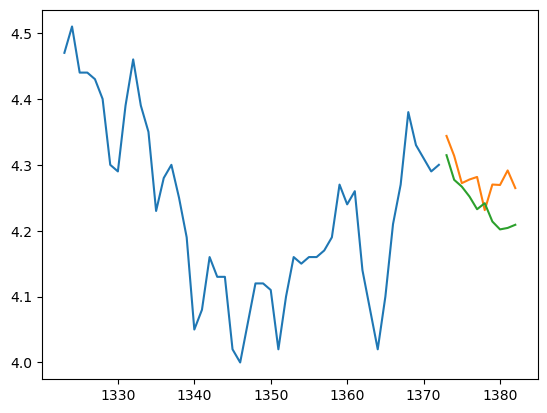

In [23]:
last_obs = 50
plt.plot(np.arange(len(series)-last_obs, len(series)), series[-last_obs:])
plt.plot(np.arange(len(series), len(series)+fh), y_pred)
plt.plot(np.arange(len(series), len(series)+fh), y_pred2)
plt.show()